In [42]:
import pandas as pd
import numpy as np
import seaborn as sns

In [43]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [44]:
param_grid={
    'C':[0.1,1,2,10],
    'kernel':['linear','rbf','poly'],
    'gamma':['scale','auto']
}

data = load_iris()
x,y = data.data, data.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)  # transform only, not fit_transform

grid_Search = GridSearchCV(SVC(),param_grid,cv=5,scoring='accuracy',verbose=2)
grid_Search.fit(x_train,y_train)
print("Best parameters:",grid_Search.best_params_)
print("Best Cross validation Accuracy:",grid_Search.best_score_)

svm_model = grid_Search.best_estimator_  # use the actual best model

y_pred = svm_model.predict(x_test)
print("Iris dataset Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("classification report:\n",classification_report(y_test,y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale

In [45]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


<Axes: >

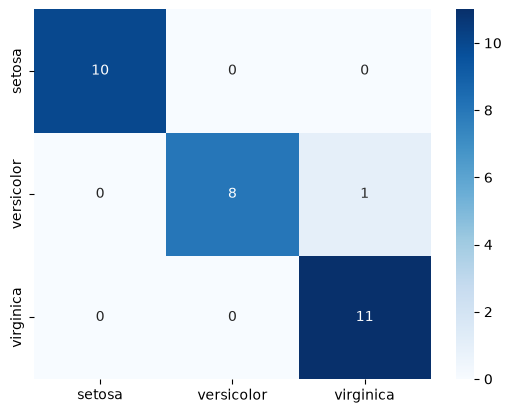

In [46]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=data.target_names,yticklabels=data.target_names)

In [47]:
import pickle

In [48]:
iris_classifier_model = (svm_model,scaler)

In [49]:
model_filename = "iris_classifier_svm_model.pkl"
with open(model_filename,'wb') as f:
    pickle.dump(iris_classifier_model,f)

In [51]:
with open("iris_classifier_svm_model.pkl", 'rb') as f:
    loaded_model = pickle.load(f)

In [52]:
svm_model, scaler = loaded_model